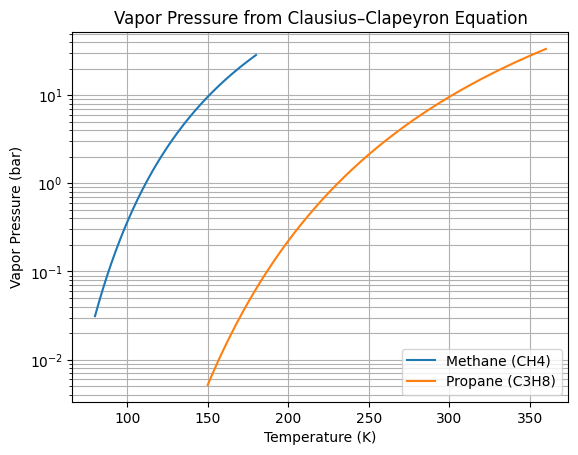

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Gas constant
R = 8.314462618  # J/mol/K

# Reference pressure (1 atm in bar)
P_ref = 1.01325

# -------------------------
# Methane properties
# -------------------------
Tboil_ch4 = 111.65  # K
hvap_ch4 = 8169.67  # J/mol (estimated from NIST correlation)

# -------------------------
# Propane properties
# -------------------------
Tboil_c3h8 = 231.04  # K
hvap_c3h8 = 18774.0  # J/mol (NIST value)

# Function to compute A and B constants
def compute_constants(hvap, Tref, Pref=P_ref):
    B = hvap / R
    A = Pref * math.exp(B / Tref)
    return A, B

A_ch4, B_ch4 = compute_constants(hvap_ch4, Tboil_ch4)
A_c3h8, B_c3h8 = compute_constants(hvap_c3h8, Tboil_c3h8)

# Temperature ranges
T_ch4 = np.linspace(80, 180, 400)
T_c3h8 = np.linspace(150, 360, 400)

# Vapor pressure equation Pv = A exp(-B/T)
Pv_ch4 = A_ch4 * np.exp(-B_ch4 / T_ch4)
Pv_c3h8 = A_c3h8 * np.exp(-B_c3h8 / T_c3h8)

# Plot
plt.figure()

plt.semilogy(T_ch4, Pv_ch4, label="Methane (CH4)")
plt.semilogy(T_c3h8, Pv_c3h8, label="Propane (C3H8)")

plt.xlabel("Temperature (K)")
plt.ylabel("Vapor Pressure (bar)")
plt.title("Vapor Pressure from Clausius–Clapeyron Equation")

plt.grid(True, which="both")
plt.legend()

plt.show()